# Employee Promotion Prediction
Predicting whether an employee is promoted or not based on various factors.
The aim is to analyze the various factors that can contribute to the promotion of an employee. Based on the analysis, we predict which employees will be promoted.

The following details for an employee is given in the dataset :-

*   Employee_id- employee id of the employee
*   Department - department of the employee
*   Region - region as designated by the company
*   Education - qualification of the employee
*   Gender - gender of the employee
*   Recruitment channel - means the channel via which employee was recruited
*   No of trainings - total number of trainings undergone by the employee
*   Age - age of the employee
*   Previous year ratings - previous year performance ratings of the employee
*   Length of service - total years worked for the company
*   Awards won - Awards won if any
*   Average training score - average score on trainings

The target column is the is_promoted column. The column is binary and specifies whether the employee was promoted or not.

--------------------------------------------------------------------------------

# Importing the required libraries

In [ ]:
from google.colab import files
import scipy as sp
import numpy as np
import pandas as pd #file handling
import seaborn as sns #visualization
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
import random
uploaded = files.upload()

Saving employee_promotion.csv to employee_promotion.csv


--------------------------------------------------------------------------------

# Loading the data

In [ ]:
import io
data = pd.read_csv(io.BytesIO(uploaded['employee_promotion.csv']))
df=data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.4+ MB


In [ ]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


Converting categorical variables to object type

In [ ]:
df['previous_year_rating']=df['previous_year_rating'].astype(object)
df['awards_won']=df['awards_won'].astype(object)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  object 
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  object 
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 5.4+ MB


In [ ]:
df.describe()

,employee_id,no_of_trainings,age,length_of_service,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,54808.000000,52248.000000,54808.000000
mean,39195.830627,1.253011,34.803915,5.865512,63.712238,0.085170
std,22586.581449,0.609264,7.660169,4.265094,13.521910,0.279137
min,1.000000,1.000000,20.000000,1.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,5.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,7.000000,77.000000,0.000000
max,78298.000000,10.000000,60.000000,37.000000,99.000000,1.000000


# Outlier Detection
Outlier detection involves realizing the possible records in the data set that might create unnecessary bias and variation in the trends and patterns. This can be done by visualizing several features against possibilities of features that can have outlying values.

1. Outlier detection in Age for every education level.


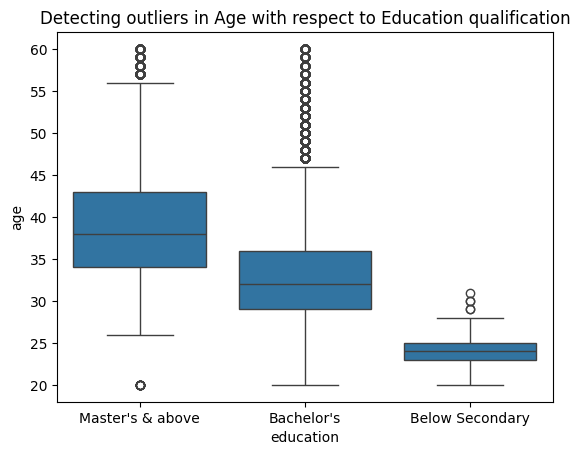

In [ ]:
ss=sns.boxplot(x='education',y='age',data=df).set(title="Detecting outliers in Age with respect to Education qualification")

Inference:
As we can see from the above box-plot, there are outliers in all education levels.
1.   Outliers above upper bound:
In all 3 education levels, we can give a logical explanation for the outlier to exist. So do not impute these outliers.

2.   Outliers below lower bound:
This case is true only for Master's and above education level. These outlier values need to be imputed as there cannot be a employee who has completed Master's at the age of 20. The lower bound value is 20.5, so imputing the outlier with the lower bound will not be useful. Hence, we impute the outlier values with the mean value.

In [ ]:
# Calculating lower and upper bound, and displaying the list of outlier values
df_2 = df[['education','age']].loc[df.education=='Master\'s & above']
Q1_M = df_2['age'].quantile(0.25)
Q3_M = df_2['age'].quantile(0.75)
IQR_M = Q3_M-Q1_M
lower_M=Q1_M-1.5*IQR_M
upper_M=Q3_M+1.5*IQR_M

# get the outliers in Master's and above education level
df2 = df[['education','employee_id','age']].loc[((df.age>upper_M) | (df.age<lower_M)) & (df.education == 'Master\'s & above')]

# Outlier imputation for Master's & above education level
for i,data in df2.iterrows():
  if data['age'] < lower_M:
      df.at[i,'age'] = np.mean(df_2['age'])

<ipython-input-4-2ebac2f4565c>:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '39.352629815745395' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[i,'age'] = np.mean(df_2['age'])


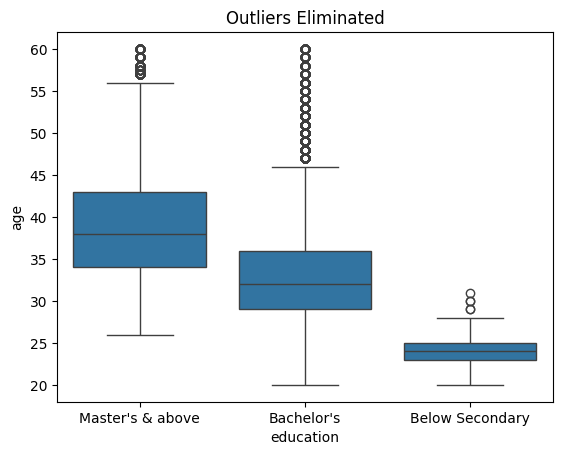

In [ ]:
ss=sns.boxplot(x='education',y='age',data=df).set(title="Outliers Eliminated")

The above box-plot confirms that the outliers below the lower bound are removed for Master's & above education level.

--------------------------------------------------------------------------------

2. Outlier imputation of length_of_service with respect to the age of the employee

In [ ]:
#Adding age categories for better visualization

df['CategoricalAge']=pd.cut(df['age'],5)
print(df[['CategoricalAge','is_promoted']].groupby(['CategoricalAge']).count())

                is_promoted
CategoricalAge             
(19.96, 28.0]         11037
(28.0, 36.0]          25652
(36.0, 44.0]          11734
(44.0, 52.0]           4273
(52.0, 60.0]           2112


<ipython-input-5-393d3b042002>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df[['CategoricalAge','is_promoted']].groupby(['CategoricalAge']).count())


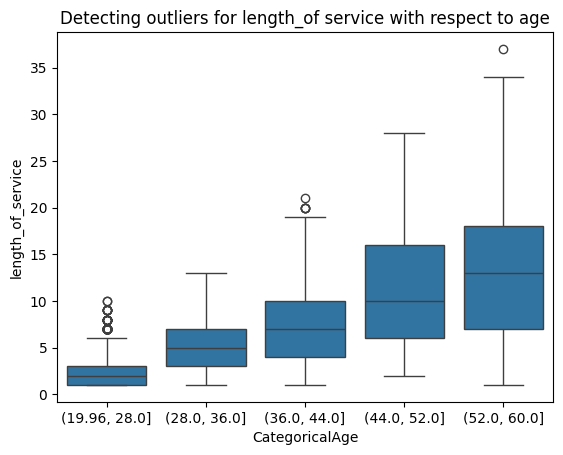

In [ ]:
#Detecting outlier in length_of_service with respect to the age of the employee

ss=sns.boxplot(x='CategoricalAge',y='length_of_service',data=df).set(title="Detecting outliers for length_of service with respect to age")

Inference:

As per the above box-plot, outliers exist for the age groups (19.96, 28.0], (36.0, 44.0] and (52.0, 60.0]. All these outliers lie above the upper bound of the respective age groups.

Outlier imputation is only required for the employees of (19.96, 28.0] age category, as an employee below the age of 28 yrs cannot have a length of service of more than 8 years.

In [ ]:
df['CategoricalAge'].unique()

[(28.0, 36.0], (36.0, 44.0], (44.0, 52.0], (19.96, 28.0], (52.0, 60.0]]
Categories (5, interval[float64, right]): [(19.96, 28.0] < (28.0, 36.0] < (36.0, 44.0] <
                                           (44.0, 52.0] < (52.0, 60.0]]

In [ ]:
#Calculating lower and upper bound, and displaying the list of outlier values
df_3 = df[['age','length_of_service']].loc[df.age<=28]
Q1 = df_3['length_of_service'].quantile(0.25)
Q3 = df_3['length_of_service'].quantile(0.75)
IQR = Q3-Q1
lower_M=Q1-1.5*IQR
upper_M=Q3+1.5*IQR

# get the outliers
df3 = df[['length_of_service','age']].loc[((df.length_of_service>upper_M) | (df.length_of_service<lower_M)) & (df.age<=28)]
df3

,length_of_service,age
1130,7,28.0
1180,7,28.0
1752,9,28.0
1794,8,28.0
1848,7,28.0
...,...,...
52977,7,28.0
53096,7,28.0
53487,7,28.0
53900,7,28.0


Outlier imputation of length_of_service of employees in the (19.96, 28.0] age group with the upper bound value.

In [ ]:
for i,data in df3.iterrows():
  if data['length_of_service'] > 7:
      df.at[i,'length_of_service'] = upper_M

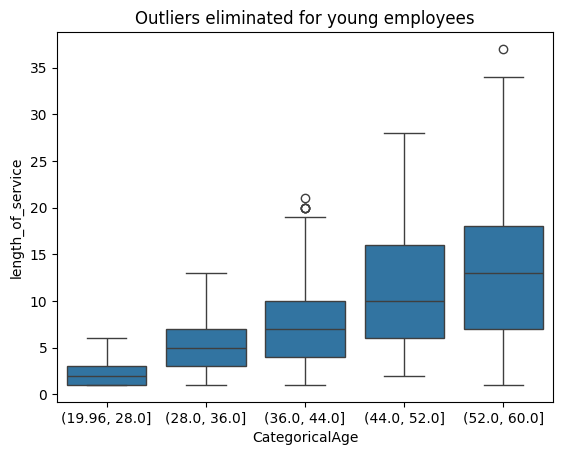

In [ ]:
ss=sns.boxplot(x='CategoricalAge',y='length_of_service',data=df).set(title="Outliers eliminated for young employees")

The above box-plot confirms that the outliers above the upper bound of age group (19.96, 28.0] have been removed.

#Missing Value Imputation

In [ ]:
#The isnull().sum() chaining counts the number of Null values per column.
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0



Only the education, previous_year_rating and avg_training score columns have null values in them.

1. Department wise imputation of education using mode.

In [ ]:
df[df.education.isna()].is_promoted.value_counts()

0    2287
1     122
Name: is_promoted, dtype: int64

It is odd that the education column has so many null values. Qualifications mean a great deal and hence it is imperative the null values are analyzed. Out of the total 2409 missing rows, 122 of those employees have recieved a promotion. Thus, the null values have to be imputed.

One solution is to impute null values in the education column with the mode. The mode of the column gives the qualification that is most frequent among the employees. The mode is a good option since during the hiring process, the company looks into the employee's qualifications and hence recruits them. It can be assumed that every department has a different criterion for qualification.

In [ ]:
# Iterate over each row
for i, data in df.iterrows():
    # Check if the education value is missing
    if pd.isna(data['education']):
        # Find mode of education for the current department
        mode_edu = df[df['department'] == data['department']]['education'].mode()[0]

        # Fill missing value with mode of education
        df.loc[i, 'education'] = mode_edu

In [ ]:
df['education'].isnull().sum()  # There are no missing values in education after imputation.

0

--------------------------------------------------------------------------------

2. Missing Value imputation of previous_year_rating with respect to the length_of_service of the employee.

The previous_year_rating column gives the rating employee recieves each year on the Likert scale (here 1 to 5). A new employee joining in the current year would not have a previous year rating, to prove this assumption, the previous year rating null values are compared to the length_of_service column which gives the number of years employee has now worked for the company. The length of service has the minimum value of 1, this implies that any new joinee is also by default said to have worked for the company for one year.

In [ ]:
service_filter = df[df.length_of_service == 1]
print(
    "Null rating counts of employees with length of service 1\n",
    service_filter.previous_year_rating.isnull().sum()
)
print(
    "Null rating counts of employees with length of service 1 and promoted\n",
    service_filter[service_filter.is_promoted == 1].previous_year_rating.isnull().sum()
)
df.previous_year_rating = df.previous_year_rating.fillna(0)

Null rating counts of employees with length of service 1
 4124
Null rating counts of employees with length of service 1 and promoted
 339


The 4124 Null values were all new employees. From these, 339 employees have actually recieved a promotion. This reason makes a compelling arguement not to remove these rows. Thus the previous_year_ratings are filled with 0s instead, making it the lowest score as well as indicating absence of value (rating) all together.

In [ ]:
for i, data in df.iterrows():
  if pd.isnull(data['previous_year_rating']):
    df.at[i,'previous_year_rating']=0

In [ ]:
df['previous_year_rating'].isnull().sum() #There are no missing values in previous_year_rating after imputation.

0

--------------------------------------------------------------------------------

3. Missing values in Average training score are imputed by assigning randomly generated values using gaussian distribution.

In [ ]:
df['avg_training_score'].isnull().sum()

2560

[Text(0.5, 1.0, 'Department VS Average Training Score')]

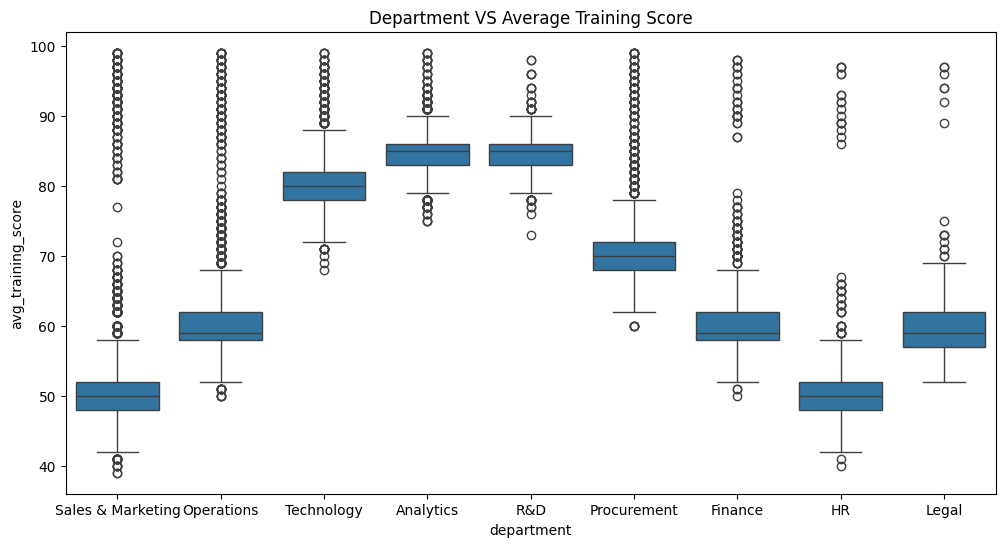

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='department',y='avg_training_score',data=df).set(title="Department VS Average Training Score")

In [ ]:
depts=df['department'].unique()
mval=[]
sval=[]
for i in depts:
  vals=df['avg_training_score'].loc[(df['department']==i)]
  mval.append(round(vals.mean(),4))
  sval.append(round(vals.std(),4))
values=pd.DataFrame({"Department":depts,"Mean":mval,"StdDev":sval})
values

,Department,Mean,StdDev
0,Sales & Marketing,50.4274,5.5396
1,Operations,60.1185,5.1346
2,Technology,79.9287,3.3555
3,Analytics,84.6030,2.8555
4,R&D,84.5966,2.9212
5,Procurement,70.1263,4.3019
6,Finance,60.1117,5.2584
7,HR,50.1825,4.6462
8,Legal,59.7162,4.3485


<ipython-input-25-0a4a9e13fff6>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['avg_training_score'].loc[df['department']==i])
<ipython-input-25-0a4a9e13fff6>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['avg_training_score'].loc[df['department']==i])
<ipython-input-25-0a4a9e13fff6>:

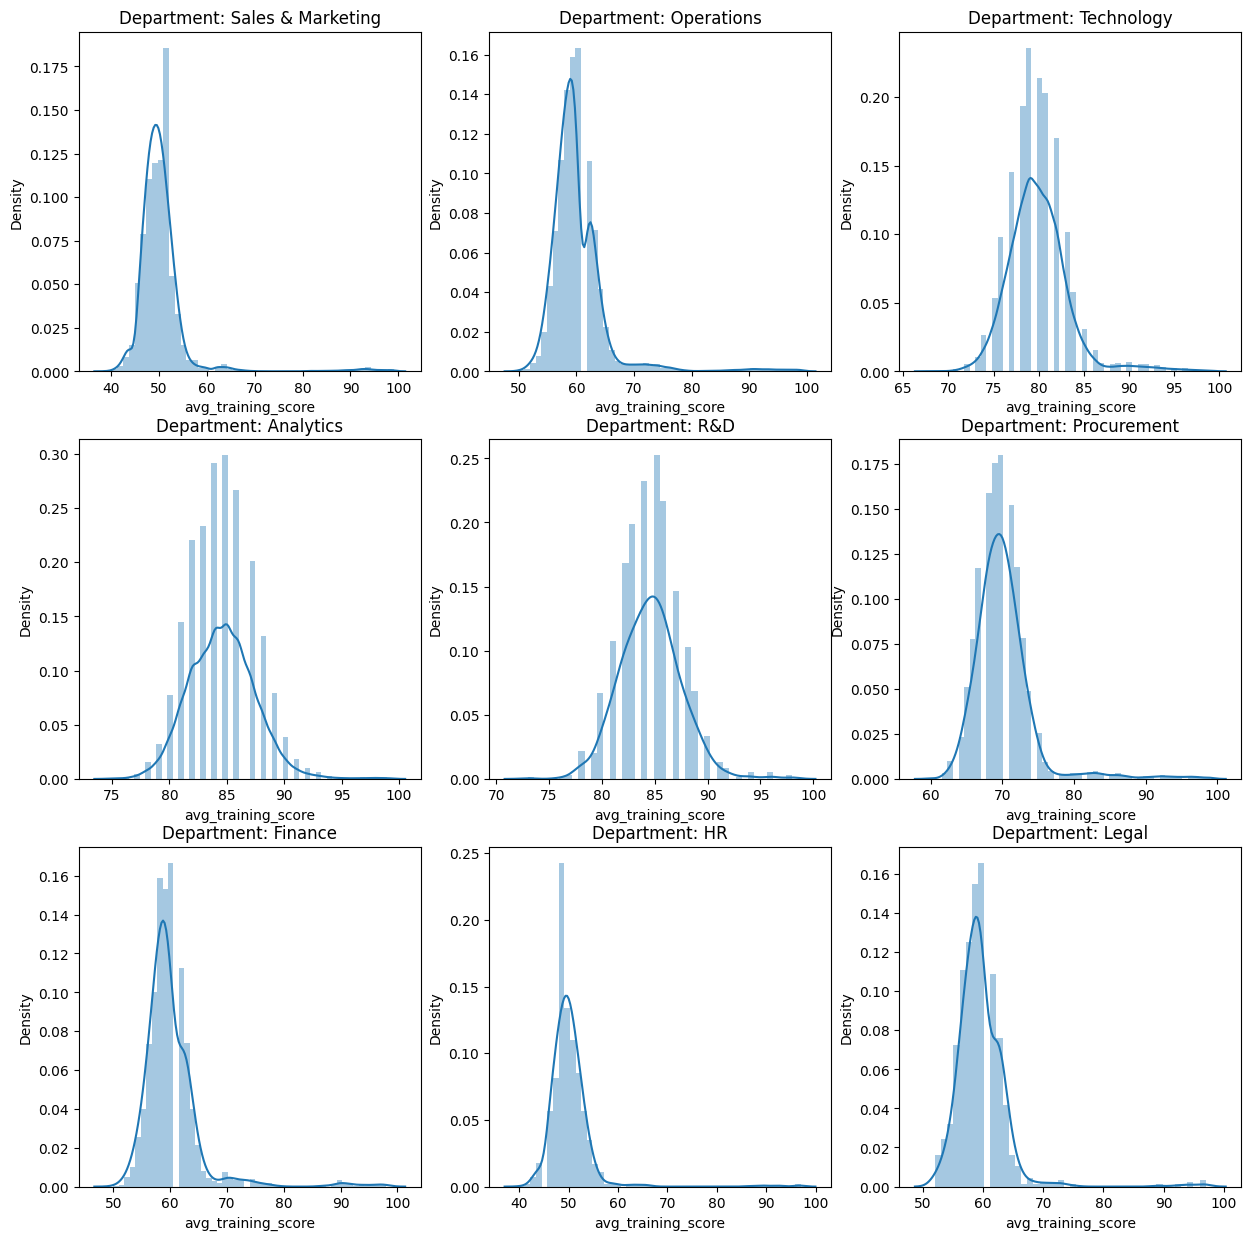

In [ ]:
plt.figure(1 , figsize = (15 , 15))
n=0
for i in depts:
  n+=1
  plt.subplot(3,3,n)
  plt.title('Department: {}'.format(i))
  sns.distplot(df['avg_training_score'].loc[df['department']==i])
plt.show()

#### Inference:
As the distribution for the average_training_score is different for each department, and the distribution of average_training_score is approximately a gaussian distribution for each department, it makes sense to impute the null values of the average training score using Gaussion Distribution for each department.

In [ ]:
for i, data in df.iterrows():
  if pd.isnull(data['avg_training_score']):
    for d in range(0,len(depts)):
      if data['department']==depts[d]:
        df.at[i,'avg_training_score']=np.random.randint(mval[d]-sval[d], mval[d]+sval[d])

In [ ]:
df['avg_training_score'].isnull().sum()

0

--------------------------------------------------------------------------------

# Data Visualization

1. Distribution of employee promotion.

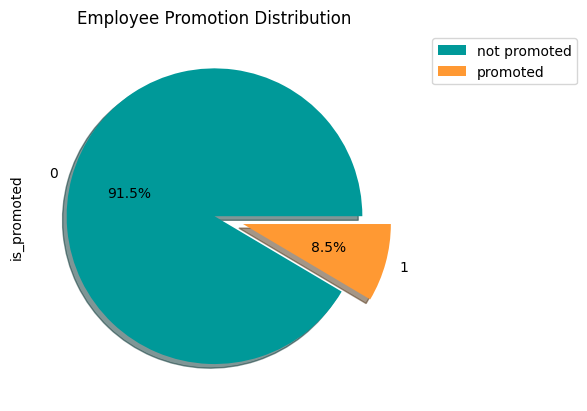

In [ ]:
df['is_promoted'].value_counts(normalize=True).plot(kind='pie', explode=[0,0.2], autopct='%1.1f%%', shadow=True, colors=['#009999','#ff9933'])
plt.title("Employee Promotion Distribution")
plt.legend(['not promoted','promoted'],loc='upper right', bbox_to_anchor=(1, 0.5, 0.5, 0.5))

Percentage of employees promoted is very less (8.5%).

2. Is the promotion of employees gender-biased?

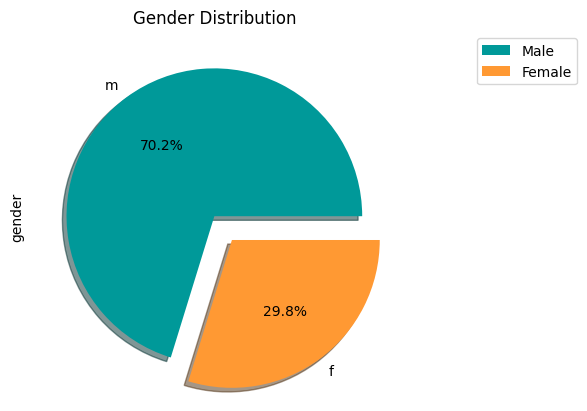

In [ ]:
#percentage of male and female employees

df['gender'].value_counts(normalize=True).plot(kind='pie', explode=[0,0.2], autopct='%1.1f%%', shadow=True, colors=['#009999','#ff9933'])
plt.title("Gender Distribution")
plt.legend(['Male','Female'],loc='upper right', bbox_to_anchor=(1, 0.5, 0.5, 0.5))

For the dataset under analysis, the percentage of male employees are more than double the female employees.

<ipython-input-32-6c9a139b9150>:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
<ipython-input-32-6c9a139b9150>:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,2,1)


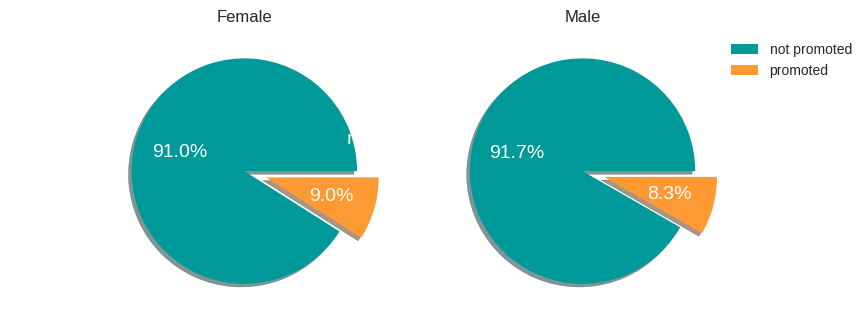

In [ ]:
plt.style.use('seaborn')
plt.subplots(figsize=(8,4))
plt.subplot(1,2,1)
plt.pie(
    x=df[df.gender=='f'].is_promoted.value_counts(normalize=True),
    labels=['not promoted','promoted'],
    explode=[0,0.2],
    autopct="%1.1f%%",
    shadow=True,
    textprops=dict(color='w',fontsize=14),
    colors=['#009999','#ff9933']
)
plt.title("Female")
plt.subplot(1,2,2)
plt.pie(
    x=df[df.gender=='m'].is_promoted.value_counts(normalize=True),
    labels=['not promoted','promoted'],
    explode=[0,0.2],
    autopct="%1.1f%%",
    shadow=True,
    textprops=dict(color='w',fontsize=14),
    colors=['#009999','#ff9933']
)
plt.title("Male")
plt.legend(['not promoted','promoted'],loc='upper right', bbox_to_anchor=(1, 0.5, 0.5, 0.5))

Inference:

The females have more promotions as compared to the males. The pie charts conclude that the two genders have equal proportions of promotions. This does not mean that equal number of females and males were promoted. As established earlier, the population of males is far greater than female. The proportions calculated are with respect to their population.

3. Relationship of promotion of employees with the length_of_service

[Text(0.5, 1.0, 'Promotion depending on Length of service')]

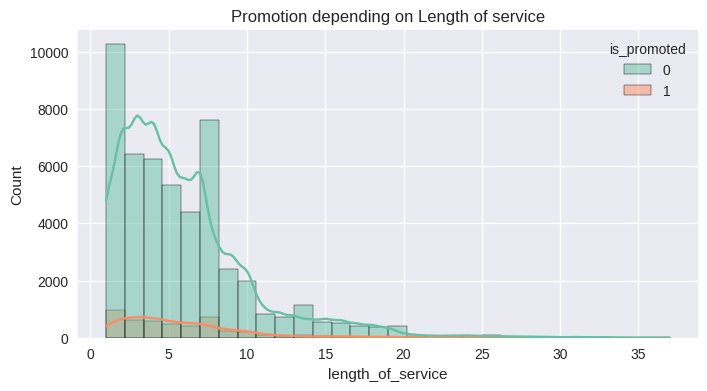

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(x='length_of_service',hue='is_promoted',data=df, palette='Set2', bins=30, kde=True).set(title="Promotion depending on Length of service")

Inference:
The employees with less than 12 years of length_of_service have received more promotions.

4. Department-wise qualifications

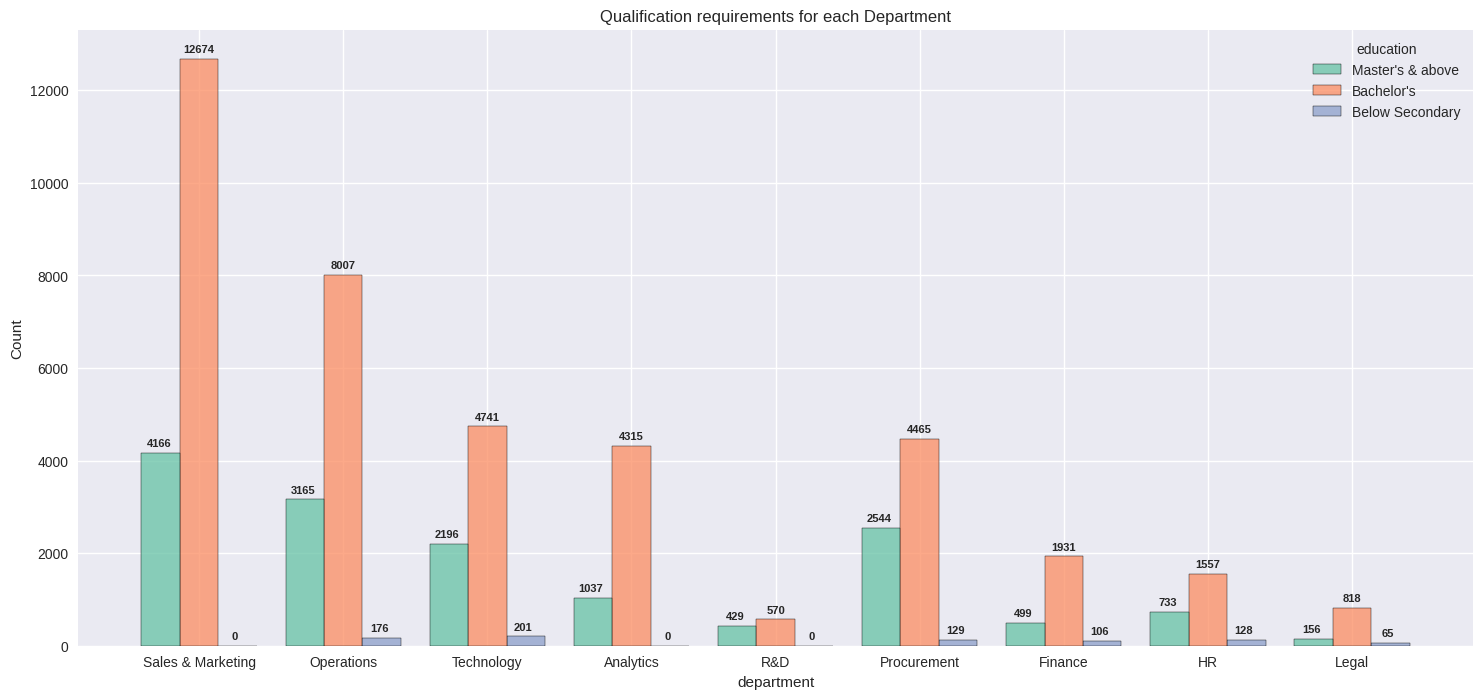

In [ ]:
plt.figure(figsize=(18,8))
l=len(df['department'].unique())
plot=sns.histplot(data=df,x='department',hue='education',multiple="dodge",shrink=0.8,palette="Set2",stat="count")
for i, bar in enumerate(plot.axes.patches):
    h = bar.get_height()
    if(i<l):
      plot.axes.text(i+0.25,h+200, '{}'.format(int(h)),ha='center',va='center', fontweight='bold', size=8)
    elif(i>=l and i<2*l):
      plot.axes.text(i-9,h+200, '{}'.format(int(h)),ha='center',va='center', fontweight='bold', size=8)
    else:
      plot.axes.text(i-18.28,h+200, '{}'.format(int(h)),ha='center',va='center', fontweight='bold', size=8)
plt.title("Qualification requirements for each Department")
plt.show()

Inferences:
<li> The least number of employees are those who haven't completed their secondary education yet.
<li>R&D and legal departments have less number of employees as compared to the other departments and R&D requires higher qualifications.

5. Relation between employee's promotion and their previous year's rating

Text(0.5, 1.0, 'Promotions based on Previous year Rating')

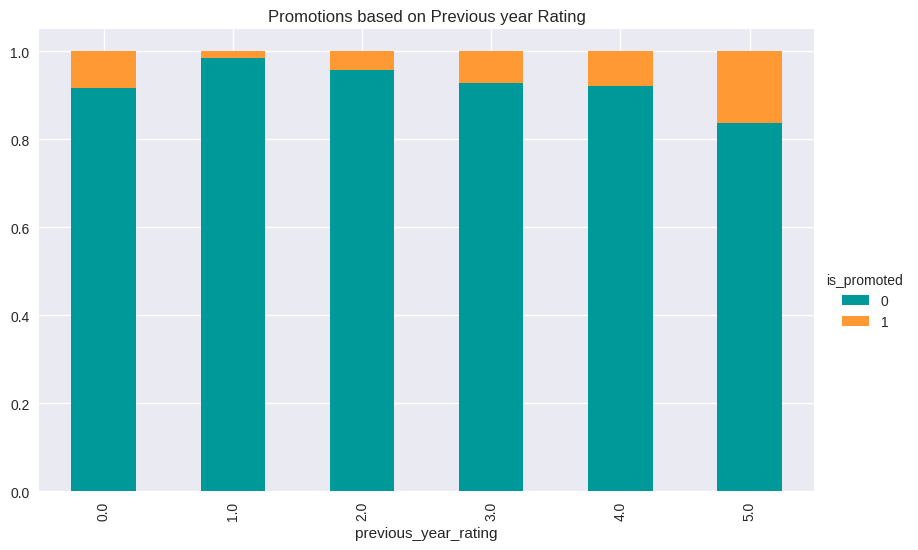

In [ ]:
colors = ['#009999','#ff9933']
plt.rcParams['figure.figsize'] = [10, 6]
score_bin = pd.crosstab(df.previous_year_rating,df.is_promoted,normalize='index')
score_bin.plot.bar(stacked=True,color=colors)
plt.legend(title='is_promoted',loc='upper left',bbox_to_anchor=(1, 0.5))
plt.title("Promotions based on Previous year Rating")

Inference:
The promotion of an employee is influenced by their previous year's rating. The proportion of promoted employees among those whose rating was 5 is greater than the proportion of employees promoted in any other rating category.

6. Percentage of promoted employees in each age group

In [ ]:
# Age categories are created for easier visualization.
# We create 4 categories as follows: Young - Less than 25 years,MiddleAged - 25 to 40 years,Experienced - 40 to 50 years,Senior - 50 years or older
for i, data in df.iterrows():
  empage=data['age']
  if(data['is_promoted']==0):
    df.loc[i,'age_label']="Not Promoted"
  else:
    if(empage<25):
      df.loc[i, 'age_label'] = "Young"
    elif(empage<40 and empage>=25):
      df.loc[i, 'age_label'] = "MiddleAged"
    elif(empage<50 and empage>=40):
      df.loc[i, 'age_label'] = "Experienced"
    elif(empage>=50):
      df.loc[i, 'age_label'] = "Senior"
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted,CategoricalAge,age_label
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35.0,5.0,8,0,49.0,0,"(28.0, 36.0]",Not Promoted
1,65141,Operations,region_22,Bachelor's,m,other,1,30.0,5.0,4,0,60.0,0,"(28.0, 36.0]",Not Promoted
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34.0,3.0,7,0,50.0,0,"(28.0, 36.0]",Not Promoted
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39.0,1.0,10,0,50.0,0,"(36.0, 44.0]",Not Promoted
4,48945,Technology,region_26,Bachelor's,m,other,1,45.0,3.0,2,0,73.0,0,"(44.0, 52.0]",Not Promoted


In [ ]:
pdata=df['age_label'].value_counts(normalize=True)
pdata

Not Promoted    0.914830
MiddleAged      0.066614
Experienced     0.012115
Senior          0.004051
Young           0.002390
Name: age_label, dtype: float64

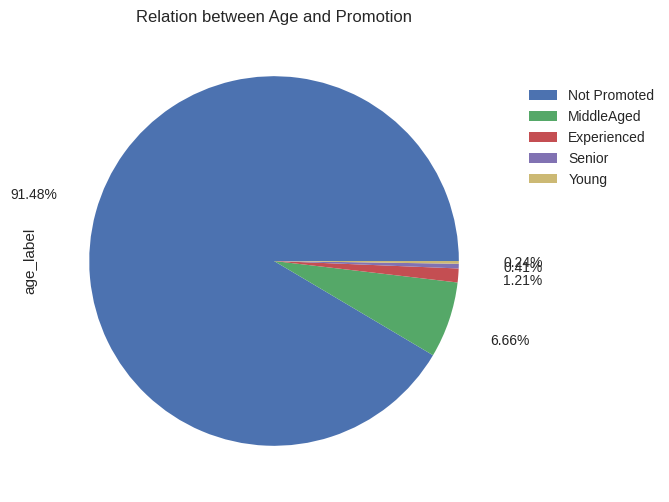

In [ ]:
pdata.plot(kind='pie',labels=None,autopct="%0.2f%%",pctdistance=1.35)
plt.title("Relation between Age and Promotion")
plt.legend(list(pdata.index),loc='upper right', bbox_to_anchor=(1, 0.45, 0.35, 0.45))

[Text(0.5, 1.0, 'Promotion depending on Age')]

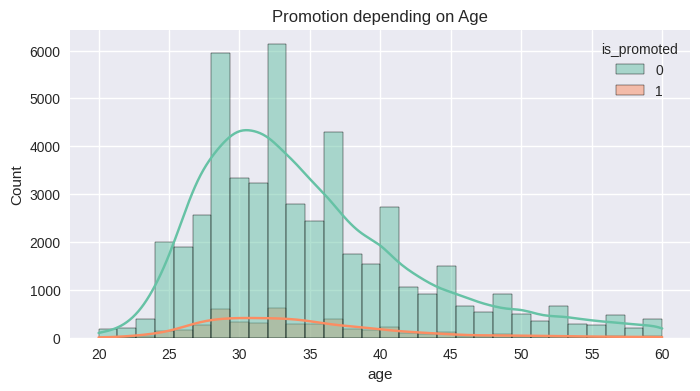

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(x='age',hue='is_promoted',data=df, palette='Set2', bins=30, kde=True).set(title="Promotion depending on Age")

Inference:

*   Middle age employees have a highest chance of being promoted as they are at the peak of their career.
*   Young employees have a lower chance of promotion as they have fewer years of work experience.
*   Elder employees have the lowest chance of promotion as they relatively close to retirement.






In [ ]:
df=df.drop('age_label',axis=1)

# Chi-Square test
As majority of our features are categorical, a chi-square test of independence is imperative in order to realize the relationship between the features.

In [ ]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won', 'avg_training_score', 'is_promoted',
       'CategoricalAge'],
      dtype='object')

In [ ]:
cols=['department', 'education', 'gender','recruitment_channel', 'no_of_trainings', 'previous_year_rating', 'awards_won','CategoricalAge','is_promoted']
data={i:[0]*len(cols) for i in cols}
chidf=pd.DataFrame(data,index=cols)

In [ ]:
for i in range(0,len(cols)):
  for j in range(0,len(cols)):
    if(cols[i]!=cols[j]):
      crosstab=pd.crosstab(df[cols[i]],df[cols[j]])
      chi2, p, dof, expected = sp.stats.chi2_contingency(crosstab)
      #print(i,j)
      #print(f"Chi2 value= {chi2} \np-value= {p} \nDegrees of freedom= {dof}\n\n")
      chidf.at[cols[i],cols[j]]=round(p,2)
    else:
      chidf.at[cols[i],cols[j]]=1

In [ ]:
chidf

,department,education,gender,recruitment_channel,no_of_trainings,previous_year_rating,awards_won,CategoricalAge,is_promoted
department,1.00,0.00,0.00,0.00,0.00,0,0.28,0.00,0.00
education,0.00,1.00,0.00,0.00,0.00,0,0.53,0.00,0.00
gender,0.00,0.00,1.00,0.08,0.00,0,0.60,0.00,0.01
recruitment_channel,0.00,0.00,0.08,1.00,0.01,0,0.33,0.00,0.00
no_of_trainings,0.00,0.00,0.00,0.01,1.00,0,0.67,0.00,0.00
previous_year_rating,0.00,0.00,0.00,0.00,0.00,1,0.00,0.00,0.00
awards_won,0.28,0.53,0.60,0.33,0.67,0,1.00,0.37,0.00
CategoricalAge,0.00,0.00,0.00,0.00,0.00,0,0.37,1.00,0.00
is_promoted,0.00,0.00,0.01,0.00,0.00,0,0.00,0.00,1.00


The chi-square test reveals that apart from the awards_won column, all the other columns are independent of each other. Therefore, all the features are statistically accurate to be included in the model.  

# Encoding

In [ ]:
le=LabelEncoder()
lb=LabelBinarizer()
Gender=lb.fit_transform(df['gender'])
df['Gender_enc']=Gender
dept_class=pd.get_dummies(df.department,prefix='Dept-')
rating_class=pd.get_dummies(df.previous_year_rating,prefix='Rating-')
edu_class=pd.get_dummies(df.education,prefix='EdLevel- ')
rec_class=pd.get_dummies(df.recruitment_channel,prefix='Rec- ')
RegionEnc=le.fit_transform(df['region'])
df['RegionEnc']=RegionEnc
df_new=pd.concat([df,edu_class,dept_class,rec_class,rating_class],axis=1,join='inner')

df_new.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,...,Dept-_Sales & Marketing,Dept-_Technology,Rec- _other,Rec- _referred,Rec- _sourcing,Rating-_1.0,Rating-_2.0,Rating-_3.0,Rating-_4.0,Rating-_5.0
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35.0,5.0,8,...,True,False,False,False,True,False,False,False,False,True
1,65141,Operations,region_22,Bachelor's,m,other,1,30.0,5.0,4,...,False,False,True,False,False,False,False,False,False,True
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34.0,3.0,7,...,True,False,False,False,True,False,False,True,False,False
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39.0,1.0,10,...,True,False,True,False,False,True,False,False,False,False
4,48945,Technology,region_26,Bachelor's,m,other,1,45.0,3.0,2,...,False,True,True,False,False,False,False,True,False,False


In [ ]:
df_new.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won', 'avg_training_score', 'is_promoted',
       'CategoricalAge', 'Gender_enc', 'RegionEnc', 'EdLevel- _Bachelor's',
       'EdLevel- _Below Secondary', 'EdLevel- _Master's & above',
       'Dept-_Analytics', 'Dept-_Finance', 'Dept-_HR', 'Dept-_Legal',
       'Dept-_Operations', 'Dept-_Procurement', 'Dept-_R&D',
       'Dept-_Sales & Marketing', 'Dept-_Technology', 'Rec- _other',
       'Rec- _referred', 'Rec- _sourcing', 'Rating-_0.0', 'Rating-_1.0',
       'Rating-_2.0', 'Rating-_3.0', 'Rating-_4.0', 'Rating-_5.0'],
      dtype='object')

In [ ]:
df_cleaned=df_new.drop(['employee_id','department','region','gender','recruitment_channel','CategoricalAge','education','previous_year_rating'],axis=1) #drop redundant columns
df_cleaned.to_csv('Cleaned_employee_promotion.csv',index=False)

# MODELS

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   no_of_trainings             54808 non-null  int64  
 1   age                         54808 non-null  float64
 2   length_of_service           54808 non-null  int64  
 3   awards_won                  54808 non-null  object 
 4   avg_training_score          54808 non-null  float64
 5   is_promoted                 54808 non-null  int64  
 6   Gender_enc                  54808 non-null  int64  
 7   RegionEnc                   54808 non-null  int64  
 8   EdLevel- _Bachelor's        54808 non-null  uint8  
 9   EdLevel- _Below Secondary   54808 non-null  uint8  
 10  EdLevel- _Master's & above  54808 non-null  uint8  
 11  Dept-_Analytics             54808 non-null  uint8  
 12  Dept-_Finance               54808 non-null  uint8  
 13  Dept-_HR                    548

In [ ]:
df_cleaned.head()

,no_of_trainings,age,length_of_service,awards_won,avg_training_score,is_promoted,Gender_enc,RegionEnc,EdLevel- _Bachelor's,EdLevel- _Below Secondary,...,Dept-_Technology,Rec- _other,Rec- _referred,Rec- _sourcing,Rating-_0.0,Rating-_1.0,Rating-_2.0,Rating-_3.0,Rating-_4.0,Rating-_5.0
0,1,35.0,8,0,49.0,0,0,31,0,0,...,0,0,0,1,0,0,0,0,0,1
1,1,30.0,4,0,60.0,0,1,14,1,0,...,0,1,0,0,0,0,0,0,0,1
2,1,34.0,7,0,50.0,0,1,10,1,0,...,0,0,0,1,0,0,0,1,0,0
3,2,39.0,10,0,50.0,0,1,15,1,0,...,0,1,0,0,0,1,0,0,0,0
4,1,45.0,2,0,73.0,0,1,18,1,0,...,1,1,0,0,0,0,0,1,0,0


In [ ]:
y=df_cleaned["is_promoted"]
x=df_cleaned.drop("is_promoted",axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.3,random_state=100)

In [ ]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_recall_fscore_support
model = LogisticRegression()
model.fit(X_train, Y_train)
lr_pred_test = model.predict(X_test)
acclr=accuracy_score(Y_test,lr_pred_test)
precisionlr,recalllr,fscorelr,supportlr=precision_recall_fscore_support(Y_test,lr_pred_test)

# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier()
rf_model.fit(X_train,Y_train)        #fit()--> implies start learning
rf_pred_test = rf_model.predict(X_test)
accrf=accuracy_score(Y_test,rf_pred_test)
precisionrf,recallrf,fscorerf,supportrf=precision_recall_fscore_support(Y_test,rf_pred_test)

#XGBoost
X_train['awards_won']=X_train['awards_won'].astype(int)
X_test['awards_won']=X_test['awards_won'].astype(int)
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
xg_model=XGBClassifier(random_state=101,enabale_categorical=True)
xg_model.fit(X_train,Y_train)
xg_pred_test=xg_model.predict(X_test)
accxg=accuracy_score(Y_test, xg_pred_test)
precisionxg,recallxg,fscorexg,supportxg=precision_recall_fscore_support(Y_test,xg_pred_test)

accdf=pd.DataFrame({'Model':['Logistic Regression','Random Forest Classifier','XGBoost Classifier'],
                    'Accuracy':[acclr,accrf,accxg],
                    'Recall(Promoted)':[round(recalllr[1],2),round(recallrf[1],2),round(recallxg[1],2)],
                    'Recall(Not Promoted)':[round(recalllr[0],2),round(recallrf[0],2),round(recallxg[0],2)],
                    'F-score (Promoted)':[round(fscorelr[1],2),round(fscorerf[1],2),round(fscorexg[1],2)],
                    'F-score (Not Promoted)':[round(fscorelr[0],2),round(fscorerf[0],2),round(fscorexg[0],2)]
                    })
accdf

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [17:22:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "enabale_categorical" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,Accuracy,Recall(Promoted),Recall(Not Promoted),F-score (Promoted),F-score (Not Promoted)
0,Logistic Regression,0.922095,0.15,1.00,0.25,0.96
1,Random Forest Classifier,0.934927,0.31,0.99,0.45,0.97
2,XGBoost Classifier,0.941373,0.36,1.00,0.51,0.97


The Recall and F-score for not_promoted is way lower than that for promoted employees, it is verified that the data is imbalanced and requires sampling in order to balance the two classes.

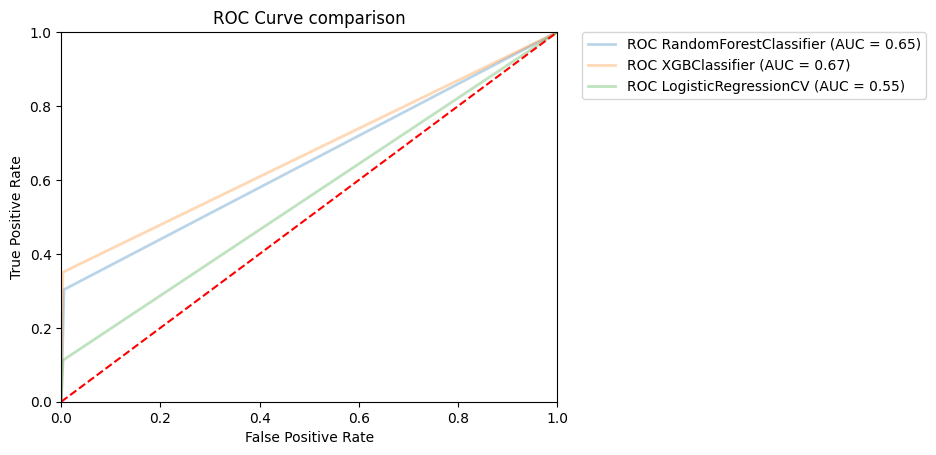

In [ ]:
from sklearn.metrics import roc_curve,auc
from sklearn import ensemble,linear_model
fp, tp, th = roc_curve(Y_test, rf_pred_test)
roc_auc_mla = auc(fp, tp)
MLA_name = ensemble.RandomForestClassifier().__class__.__name__
plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
fp, tp, th = roc_curve(Y_test, xg_pred_test)
roc_auc_mla = auc(fp, tp)
MLA_name = XGBClassifier().__class__.__name__
plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
fp, tp, th = roc_curve(Y_test, lr_pred_test)
roc_auc_mla = auc(fp, tp)
MLA_name = linear_model.LogisticRegressionCV().__class__.__name__
plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))

plt.title('ROC Curve comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

The ROC Curve comparison reveals that the XGBClassifier is the best among the three but the True Positive Rates are not at the levels which are optimally required.

In [ ]:
from imblearn.over_sampling import SMOTE
#smote: synthetic minority oversampling technique
sm=SMOTE(random_state=200)
X_res, y_res = sm.fit_resample(x, y)
X_res = pd.DataFrame(X_res)
Y_res = pd.DataFrame(y_res)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_res,Y_res,test_size=0.3,random_state=100)
model = LogisticRegression()
model.fit(X_train, Y_train)
lr_pred_test = model.predict(X_test)
lr_conf_matrix=confusion_matrix(Y_test,lr_pred_test)
print("confusion matrix:\n",lr_conf_matrix)
print("-------------------------------------------------------------")
print("Classification report: \n",classification_report(Y_test,lr_pred_test))

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


confusion matrix:
 [[13775  1257]
 [ 2309 12743]]
-------------------------------------------------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.92      0.89     15032
           1       0.91      0.85      0.88     15052

    accuracy                           0.88     30084
   macro avg       0.88      0.88      0.88     30084
weighted avg       0.88      0.88      0.88     30084



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
rf_model=RandomForestClassifier()
rf_model.fit(X_train,Y_train)
rf_pred_test = rf_model.predict(X_test)
rf_conf_matrix=confusion_matrix(Y_test,rf_pred_test)
print("confusion matrix:\n",rf_conf_matrix)
print("-------------------------------------------------------------")
print("Classification report: \n",classification_report(Y_test,rf_pred_test))

<ipython-input-62-635a3a382ea8>:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_model.fit(X_train,Y_train)        #fit()--> implies start learning


confusion matrix:
 [[14761   271]
 [  925 14127]]
-------------------------------------------------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     15032
           1       0.98      0.94      0.96     15052

    accuracy                           0.96     30084
   macro avg       0.96      0.96      0.96     30084
weighted avg       0.96      0.96      0.96     30084



In [ ]:
X_train['awards_won']=X_train['awards_won'].astype(int)
X_test['awards_won']=X_test['awards_won'].astype(int)
xg_model=XGBClassifier(random_state=101,enabale_categorical=True)
xg_model.fit(X_train,Y_train)
xg_pred_test=xg_model.predict(X_test)
xg_confusion_matrix=confusion_matrix(Y_test, xg_pred_test)
print("confusion matrix:\n",xg_confusion_matrix)
print("-------------------------------------------------------------")
print("Classification report: \n",classification_report(Y_test,xg_pred_test))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [16:30:01] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "enabale_categorical" } are not used.

  warnings.warn(smsg, UserWarning)


confusion matrix:
 [[14938    94]
 [ 1195 13857]]
-------------------------------------------------------------
Classification report: 
               precision    recall  f1-score   support

           0       0.93      0.99      0.96     15032
           1       0.99      0.92      0.96     15052

    accuracy                           0.96     30084
   macro avg       0.96      0.96      0.96     30084
weighted avg       0.96      0.96      0.96     30084



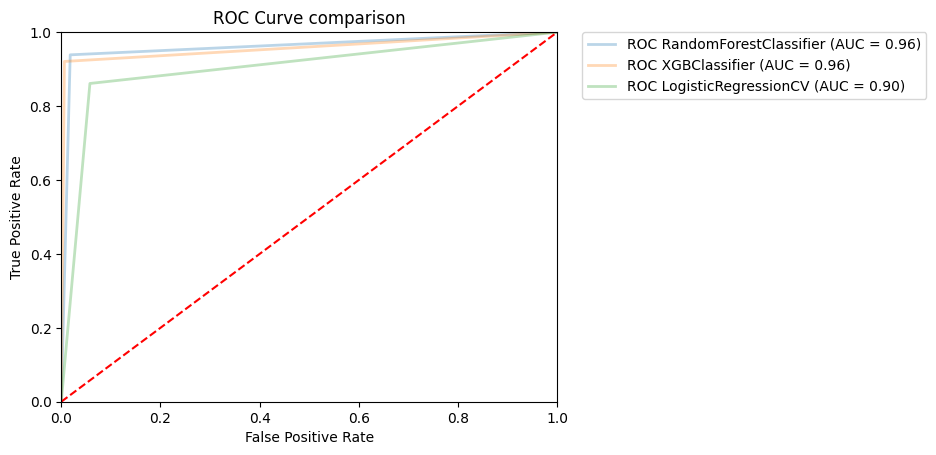

In [ ]:
fp, tp, th = roc_curve(Y_test, rf_pred_test)
roc_auc_mla = auc(fp, tp)
MLA_name = ensemble.RandomForestClassifier().__class__.__name__
plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
fp, tp, th = roc_curve(Y_test, xg_pred_test)
roc_auc_mla = auc(fp, tp)
MLA_name = XGBClassifier().__class__.__name__
plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
fp, tp, th = roc_curve(Y_test, lr_pred_test)
roc_auc_mla = auc(fp, tp)
MLA_name = linear_model.LogisticRegressionCV().__class__.__name__
plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))

plt.title('ROC Curve comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Since the accuracy has increased significantly to 96%, the Recalls and F-scores are balanced for both the classes and the precision for both the classes are more than 90%, the models have been optimized.

# THANK YOU